# K-means

La primera parte de esta práctica tiene como objetivo proporcionar una comprensión sobre el uso del paquete `sklearn.cluster.KMeans` el cual utilizaremos como implementacion del algoritmo de M-means sobre datos generados de manera sintetica ayudados del paquete `sklearn.datasets.make_blobs` y `sklearn.datasets.make_circles`. Para mas informacion de estas dos herramientas pueden consultar: https://scikit-learn.org/stable/user_guide.html

In [2]:
!pip install yellowbrick

In [3]:
#Importar paquetes
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_circles

from imblearn.over_sampling import SMOTE

from sklearn.metrics import silhouette_score,silhouette_samples
from yellowbrick.cluster import SilhouetteVisualizer

## a) Generación de datos:
Utilizaremos make_blobs para crear 4 dataset con propiedades distintas (**Nota**: Esta subsección está completamente terminada no es necesario cambiar el código)

In [4]:
n_samples = 1500
random_state = 123

#DataSet 1
X, y = make_blobs(n_samples=n_samples, random_state=random_state)

#DataSet 2
X_varied, y_varied = make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)

#DataSet 3
X_filtered = np.vstack((X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]))
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

#DataSet 4
X_circle, y_circle = make_circles(n_samples=n_samples, random_state=random_state,noise=0.1,factor=0.5)

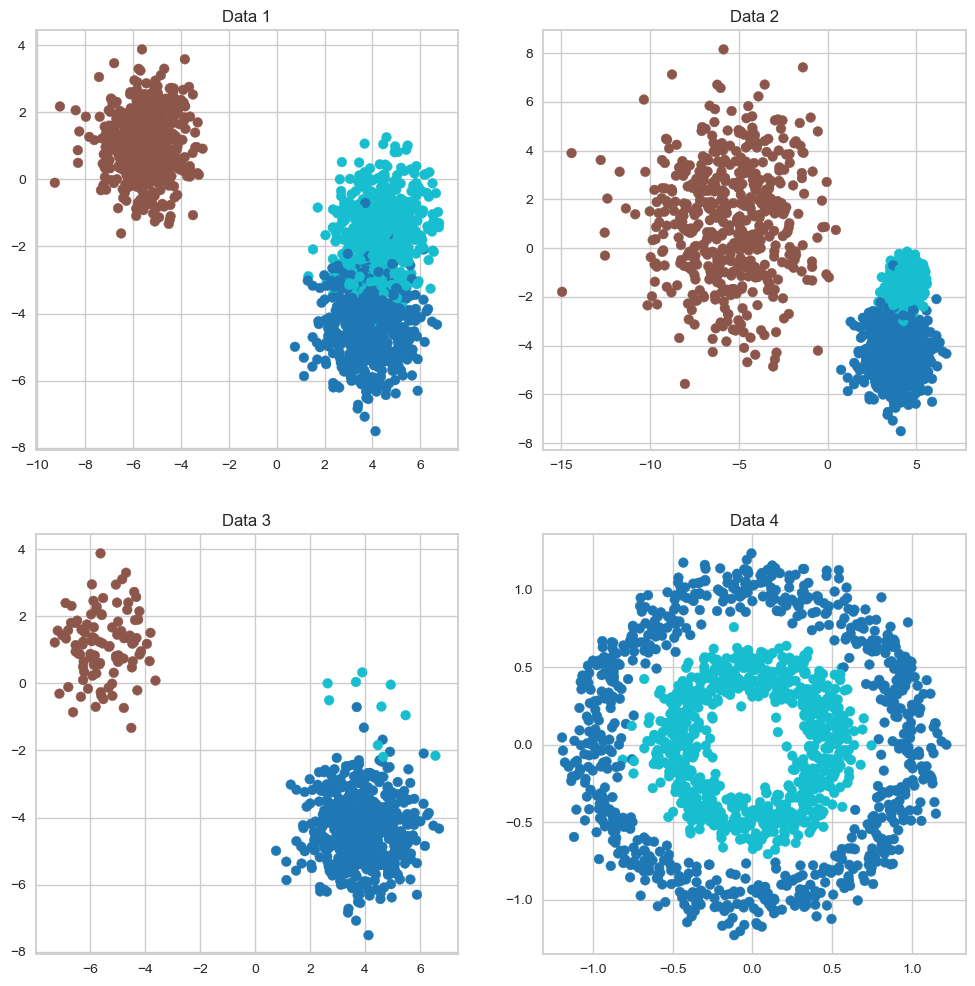

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y,cmap="tab10")
axs[0, 0].set_title("Data 1")

axs[0, 1].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied,cmap="tab10")
axs[0, 1].set_title("Data 2")

axs[1, 0].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered,cmap="tab10")
axs[1, 0].set_title("Data 3")

axs[1, 1].scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle,cmap="tab10")
axs[1, 1].set_title("Data 4")

plt.show()

### <font color='red'> Pregunta 1: <font color='black'> Explica cuales son las principales características de cada dataset, además explica si el algoritmo k-mean podrá agrupar los datos presentados, justifica tu respuesta.

### <font color='red'> Responde aqui

Data 1:
Cada grupo tiene una dispersión similar y están claramente separados en el espacio. Ademas, las clases son aproximadamente esféricas y de tamaño comparable. 
El algoritmo K-means asume que los clusters son aproximadamente esféricos, de tamaño similar y separados linealmente, condiciones que este dataset cumple perfectamente.

Data 2:
También presenta tres grupos, pero cada uno tiene una dispersión distinta.
K-means tendra alguna dificultad, ya que no maneja bien clusters con varianzas muy diferentes, porque su criterio de agrupamiento tiende a dividir los grupos grandes y fusionar los pequeños. Por lo que, puede asignar incorrectamente puntos del cluster más disperso a otros centroides más cercanos.

Data 3:
Tres grupos con tamaños muy diferentes, los clusters están desbalanceados, lo que genera una distribución muy desigual en densidad.
K-means minimiza la suma de distancias cuadradas al centroide, por lo que los grupos grandes dominan la función objetivo, los clusters pequeños, como el de 10 puntos, pueden ser absorbidos por otros o no ser detectados.

Data 4:
Dos conjuntos de puntos con forma circular concéntrica, no hay separación lineal entre los grupos, uno rodea completamente al otro.
K-means no funcionara en este caso, ya que el algoritmo agrupa según distancia euclidiana, dividirá los círculos por proximidad lineal. Por ejemplo, cortará los circulos en dos partes, en lugar de separar los círculos interior y exterior.


# b) Implementación de K-mean:

Esta sección se centra en la implementación del algoritmo de k-means, usa como referencia el siguiente código para **procesar cada una de las bases de datos**.

C:\Users\victo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\victo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\victo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\victo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

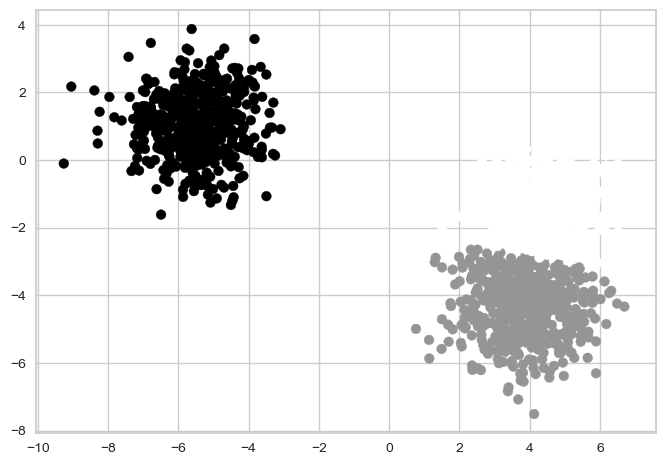

In [6]:
y_pred = KMeans(n_clusters=3, random_state=123, init='random').fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.show()

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


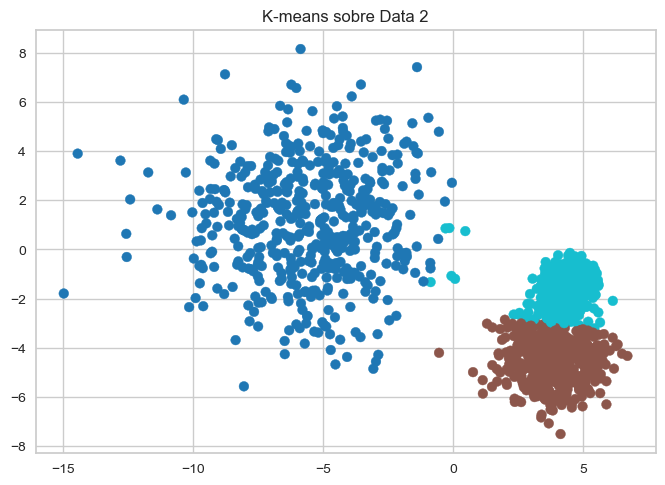

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


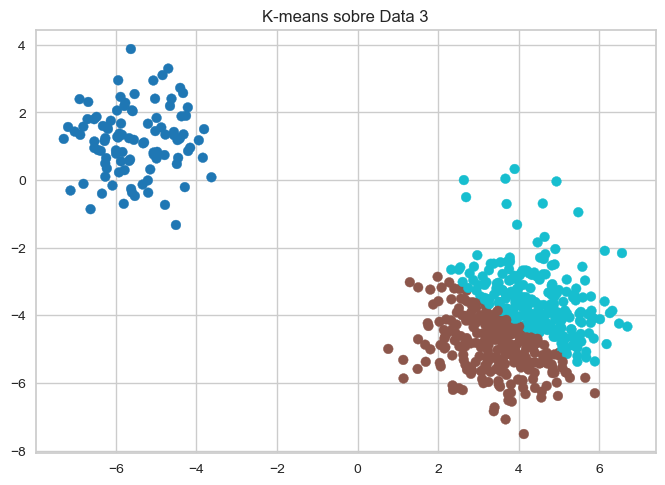

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


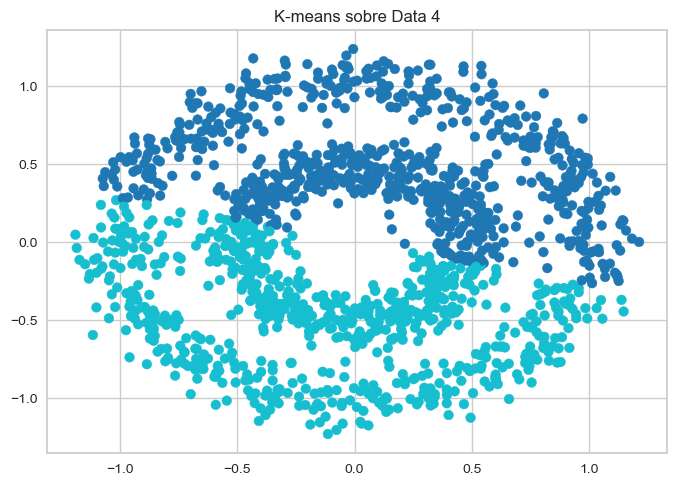

In [9]:
#coloca aqui el codigo para las siguientes bases de datos
# Data 2
y_pred2 = KMeans(n_clusters=3, random_state=123, init='random').fit_predict(X_varied)
plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred2, cmap="tab10")
plt.title("K-means sobre Data 2")
plt.show()

# Data 3
y_pred3 = KMeans(n_clusters=3, random_state=123, init='random').fit_predict(X_filtered)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred3, cmap="tab10")
plt.title("K-means sobre Data 3")
plt.show()

# Data 4
y_pred4 = KMeans(n_clusters=2, random_state=123, init='random').fit_predict(X_circle)
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_pred4, cmap="tab10")
plt.title("K-means sobre Data 4")
plt.show()

### <font color='red'> Pregunta 2: <font color='black'> Discute los resultados obtenidos y compararlos con tu analisis realizado en la pregunta anterior.


### <font color='red'> Responde aqui

Data 1:
El algoritmo K-means logra separar los tres grupos de forma casi perfecta. Cada cluster recuperado coincide con los grupos originales. Coincide completamente con lo esperado.

Data 2:
K-means separa los clusters de forma aceptable, pero se observa algun error en los bordes. Algunos puntos del cluster más disperso se asignan a otros grupos. Tal como hemos dicho, K-means no maneja demasiado bien la diferencia en la varianza, aunque los resultados son bastante buenos.

Data 3:
El algoritmo no ha sido capaz de representar el grupo con 10 miembros, el grupo pequeño ha absorbido parte de los puntos del grupo grande mas proximo, distorsionando la realidad de los grupos. Como nos imaginabamos, K-means tiene muchas dificultades cuando el tamaño de los grupos es tan desigual. 

Data 4:
K-means no logra capturar la estructura circular. En lugar de separar el círculo interior del exterior, corta los datos de forma lineal, dividiendo los círculos en dos partes.




### <font color='red'> Pregunta 3: <font color='black'> Explica los parámetros `n_clusters=3`, `random_state=123` e `init='random'` y cómo influyen en las predicciones.
### <font color='red'> Responde aqui

n_clusters = 3
Indica el número de grupos (clusters) que el algoritmo K-means debe buscar en los datos.

random_state = 123
Establece una semilla aleatoria fija para el generador de números aleatorios que usa K-means.

init = 'random'
Indica el método de inicialización de los centroides, en este caso el parametro 'random' elige aleatoriamente los puntos iniciales de los centroides.


# c) Selección de `n_clusters`:


En esta sección veremos cómo afecta a nuestra predicción el parámetro `n_clusters`, para ello **toma el DataSet 2 y muestra las gráficas para distintos valores de `n_clusters`, iniciando desde 2 hasta 5**.

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

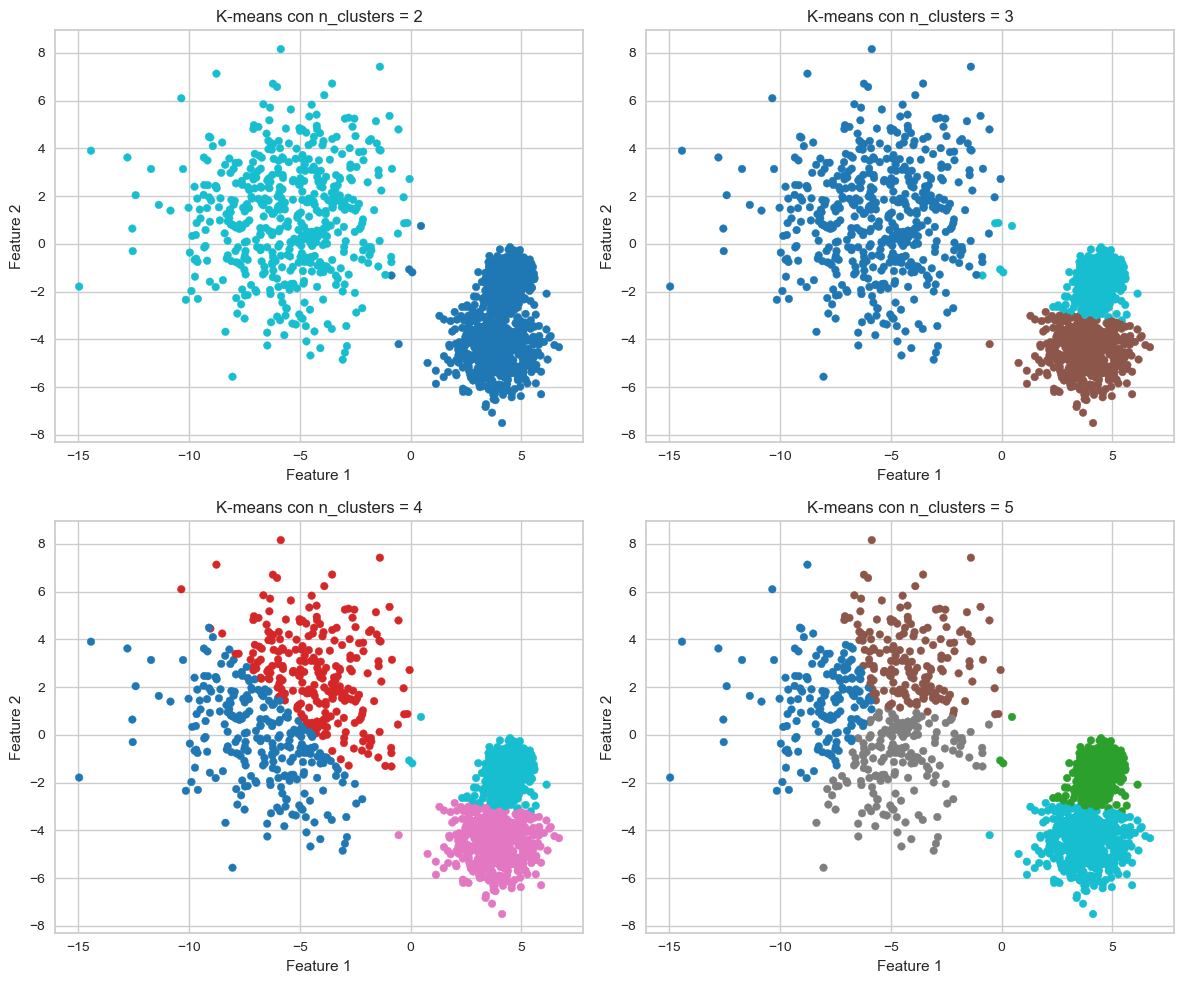

In [10]:
#for c in range(2,6):
  #completa el codigo aqui para mostrar las predicciones realizadas por kmeans
  #con diferentes numeros de n_clusters

plt.figure(figsize=(12, 10))
for i, c in enumerate(range(2, 6), 1): 
    kmeans = KMeans(n_clusters=c, random_state=123, init='random')
    y_pred = kmeans.fit_predict(X_varied)

    plt.subplot(2, 2, i)
    plt.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred, cmap="tab10", s=30)
    plt.title(f"K-means con n_clusters = {c}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

### <font color='red'> Pregunta 4: <font color='black'> Es posible que en un problema real no contemos con la información de la clase de cada muestra (los diferentes colores), ¿Hay algún valor de `n_clusters` que visualmente haga un buen agrupamiento sin tomar en cuenta los colores verdaderos? Detalla tu respuesta


### <font color='red'> Responde aqui

Sin tomar en cuenta los valores reales, el n_clusters=2 nos proporciona una agrupación muy buena, hay dos grupos que estan muy bien definidos, esto es debido a que existen dos grupos muy cercanos que el algoritmo identifica como uno solo.
Obviamente el n_clusters=3 hace un muy buen agrupamiento.
Para n_clusters = 4 o 5, el algoritmo divide clusters existentes en varios subgrupos más pequeños. Se observan regiones del mismo color muy próximas o superpuestas, lo que indica sobreajuste

Visualmente podemos comparar los resultados con las etiquetas reales en este problema gracias a su baja dimensionalidad y complejidad, sin embargo esto no es algo usual, por lo que tomar la decisión de cuántos clusters es el número correcto es más complicado. En este apartado veremos dos herramientas que pueden ayudar a tomar una decisión `silhouette_score` e `inertia` (Elbow Curve).


* **Silhouette** Es un indicador de la calidad de los clusters obtenidos en términos de cómo son de similares los datos en el mismo cluster respecto de los datos que están en otros clusters. Relaciona las distancias intra-cluster con las distancias inter-clusters. Es un indicador adecuado para K-Means porque, como sabemos, éste trata de minimizar las distancias intra-cluster de los datos. El indicador (Score) Silhouette se calcula para cada dato del dataset. Para ello se calculan para cada dato $p$ de los clusters obtenidos por K-Means las siguientes cantidades:
Distancia media de las distancias entre el punto $p$ y el resto de puntos del cluster. La llamamos $a$.
Distancia media de la distancia entre cada punto de un cluster y los puntos del cluster más cercano. La llamamos $b$
El indicador (Score) Silhouette $S$ para cada punto $p$ se calcula como se define como: $$S_p = \frac{(b - a)}{max(a, b)}$$

El valor de Silhouette varia de -1 a 1. Si el score es cercano a 1 para todos los datos de un cluster, indica que este cluster es denso y bien separado del resto de clusters. Un valor del score cercano a 0 para todos los puntos indica que hay clusters que se entremezclan (overlapping) con datos que están muy cerca de la frontera de decisión entre dos clusters. Un score negativo (cercano a -1) indica que os ejemplos se han asignado a clusters equivocados.

* **Elbow Curve** representa de manera gráfica el valor de la suma de las distancias al cuadrado de las muestras al centro de su grupo más cercano (inertia) para cada valor de cluster utilizado




**Usa como ejemplo el siguiente código para replicarlo en el resto de bases de datos**


C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

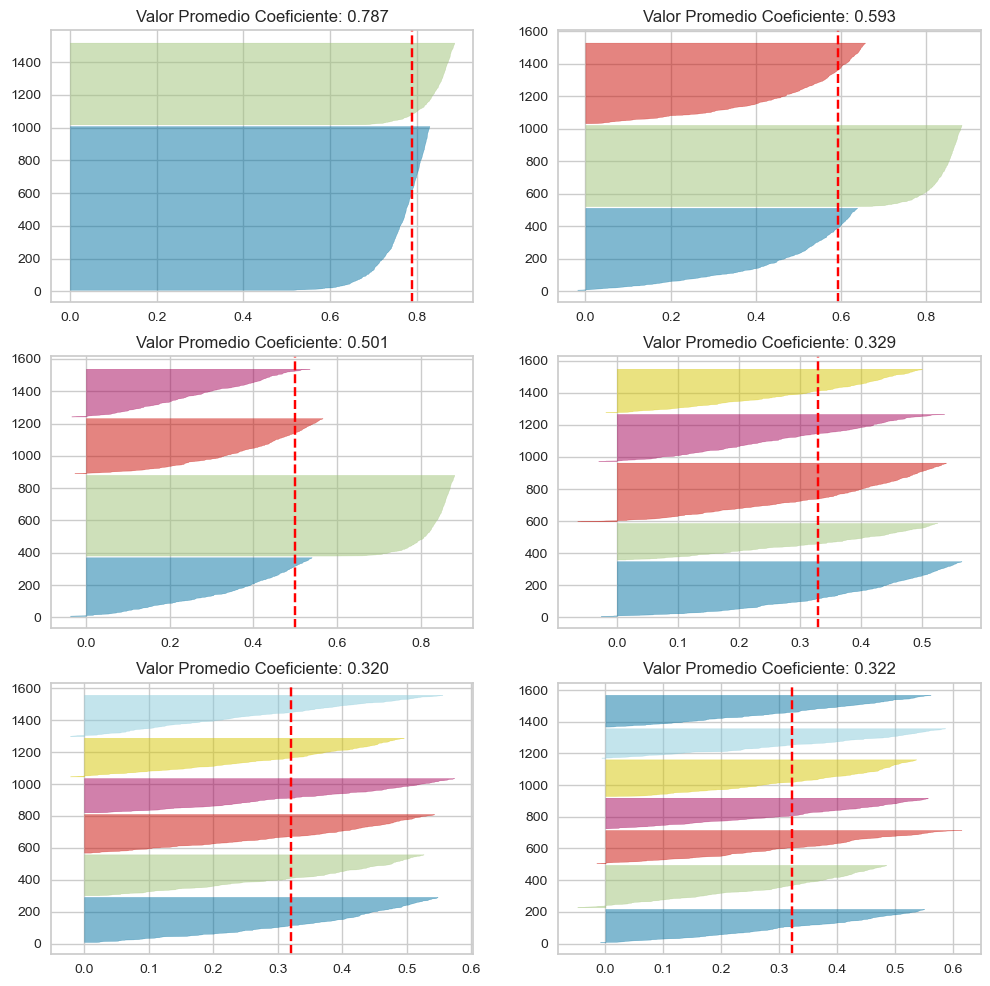

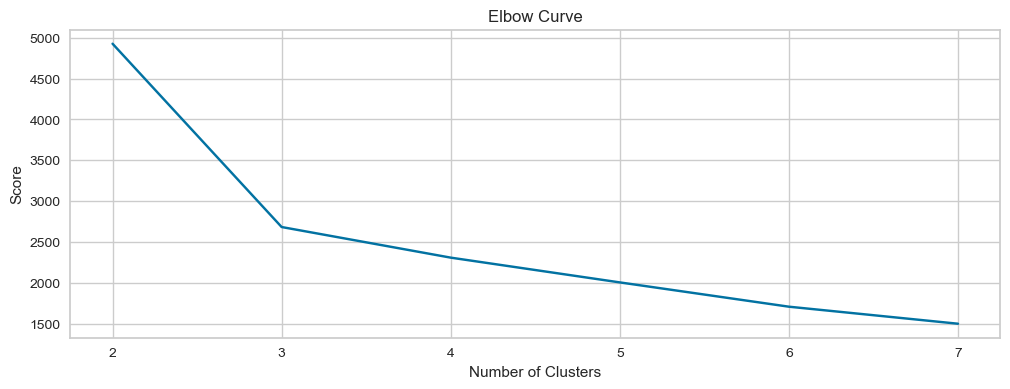

In [11]:
#Dataset 1

#Seleccionamos un rango de clusters a analizar
n_clusters=[2, 3, 4, 5, 6, 7]

fig, ax = plt.subplots(3, 2, figsize=(12,12))
scores=[]
for c in n_clusters:
    #definimos el metodo KMeans
    km = KMeans(n_clusters=c, init='k-means++', n_init=10, random_state=123)
    q, mod = divmod(c, 2)
    km.fit(X)

    #recolectamos en un vector los valores de inertia
    scores.append(km.inertia_)

    #calculamos el silhouette score y mostramos su grafica
    score = silhouette_score(X, km.labels_, metric='euclidean')
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    leyenda= "Valor Promedio Coeficiente: %.3f" % (score)
    visualizer.set_title(leyenda)
    visualizer.fit(X)
plt.show()

#Graficamos los valores de inertia para cada numero de cluster
plt.figure(figsize=(12,4))
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.plot(n_clusters,scores)
plt.show()

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

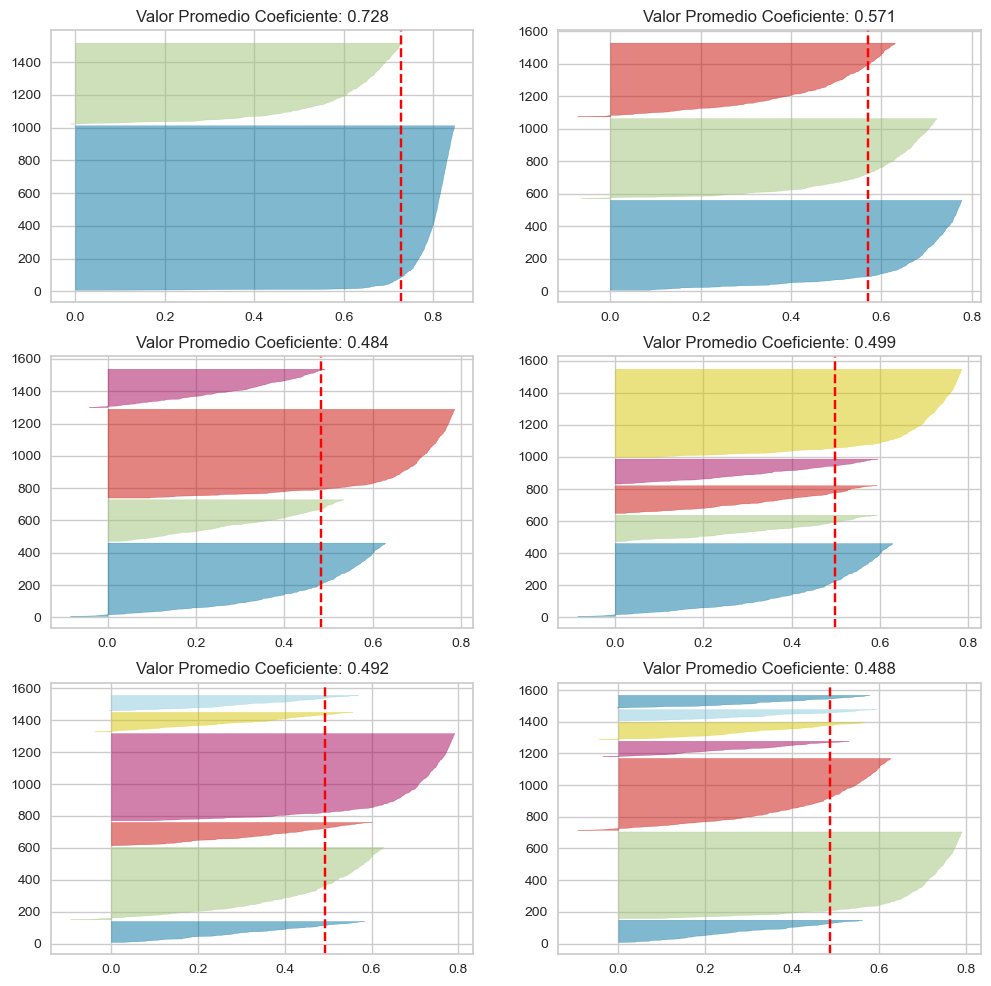

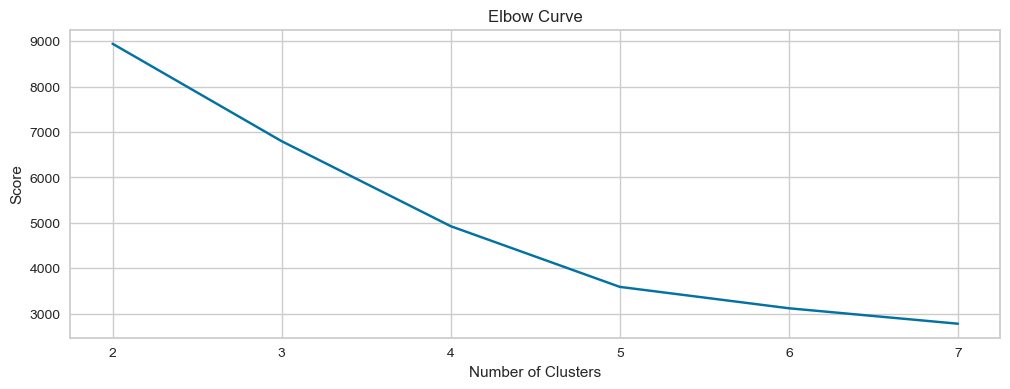

In [12]:
#Agrega el codigo para el resto de bases de datos
#Dataset 2

#Seleccionamos un rango de clusters a analizar
n_clusters=[2, 3, 4, 5, 6, 7]

fig, ax = plt.subplots(3, 2, figsize=(12,12))
scores=[]
for c in n_clusters:
    #definimos el metodo KMeans
    km = KMeans(n_clusters=c, init='k-means++', n_init=10, random_state=123)
    q, mod = divmod(c, 2)
    km.fit(X_varied)

    #recolectamos en un vector los valores de inertia
    scores.append(km.inertia_)

    #calculamos el silhouette score y mostramos su grafica
    score = silhouette_score(X_varied, km.labels_, metric='euclidean')
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    leyenda= "Valor Promedio Coeficiente: %.3f" % (score)
    visualizer.set_title(leyenda)
    visualizer.fit(X_varied)
plt.show()

#Graficamos los valores de inertia para cada numero de cluster
plt.figure(figsize=(12,4))
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.plot(n_clusters,scores)
plt.show()

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

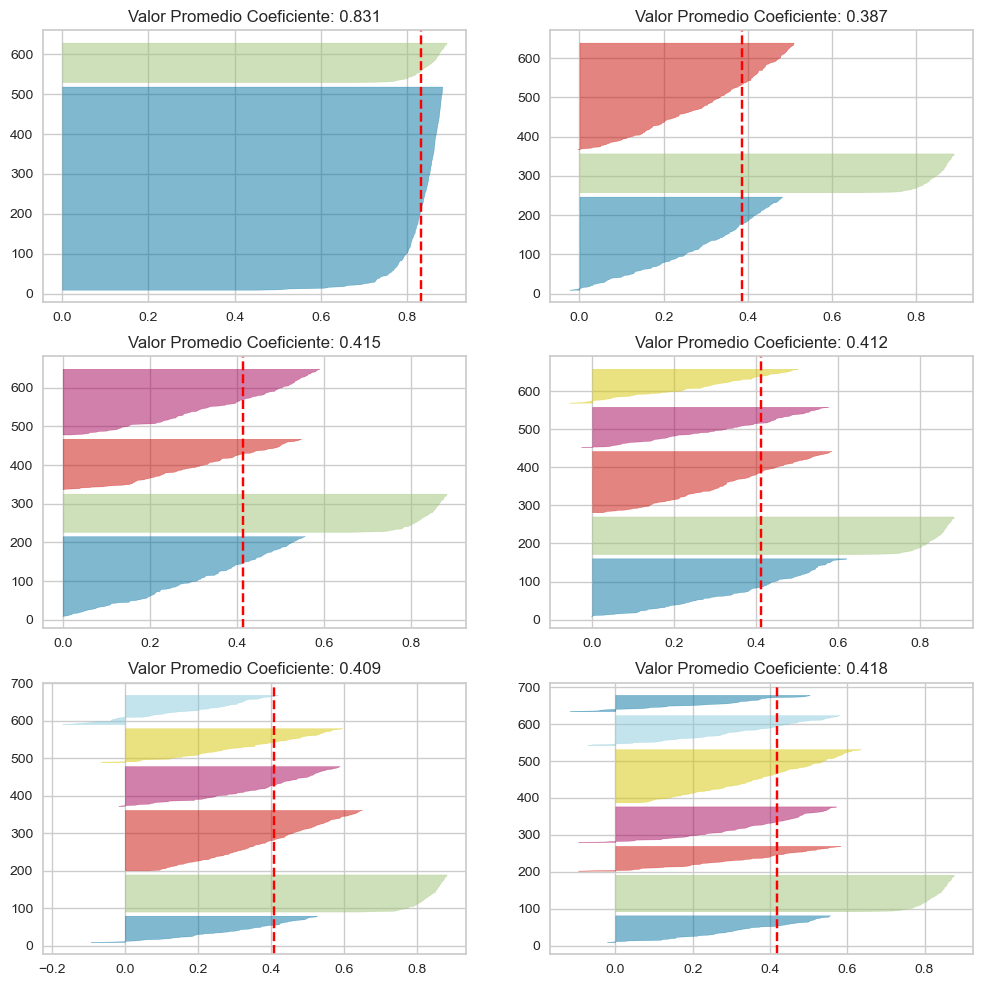

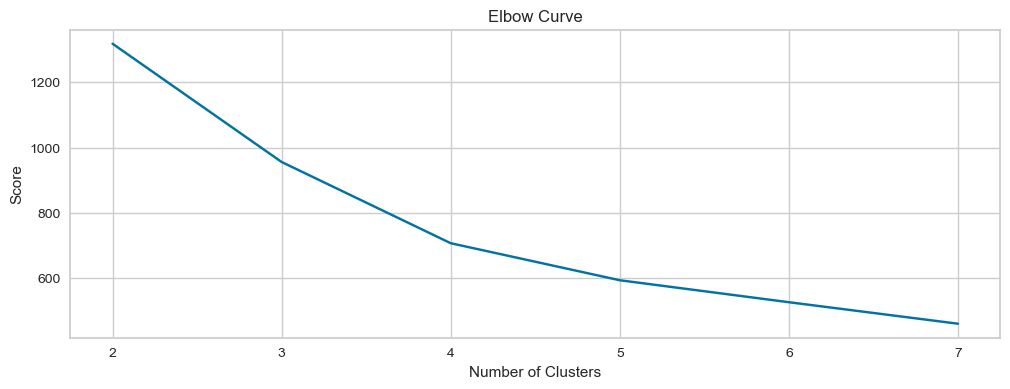

In [13]:
#Dataset 3

#Seleccionamos un rango de clusters a analizar
n_clusters=[2, 3, 4, 5, 6, 7]

fig, ax = plt.subplots(3, 2, figsize=(12,12))
scores=[]
for c in n_clusters:
    #definimos el metodo KMeans
    km = KMeans(n_clusters=c, init='k-means++', n_init=10, random_state=123)
    q, mod = divmod(c, 2)
    km.fit(X_filtered)

    #recolectamos en un vector los valores de inertia
    scores.append(km.inertia_)

    #calculamos el silhouette score y mostramos su grafica
    score = silhouette_score(X_filtered, km.labels_, metric='euclidean')
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    leyenda= "Valor Promedio Coeficiente: %.3f" % (score)
    visualizer.set_title(leyenda)
    visualizer.fit(X_filtered)
plt.show()

#Graficamos los valores de inertia para cada numero de cluster
plt.figure(figsize=(12,4))
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.plot(n_clusters,scores)
plt.show()

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

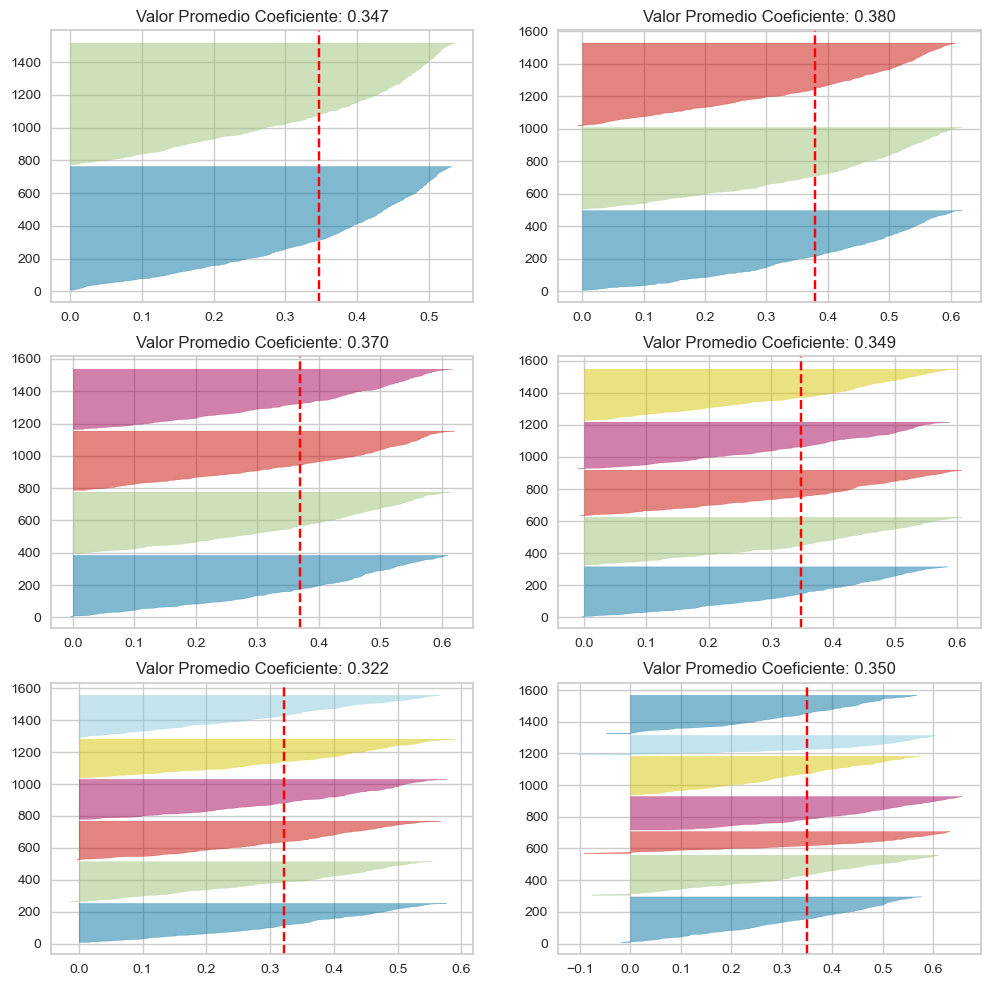

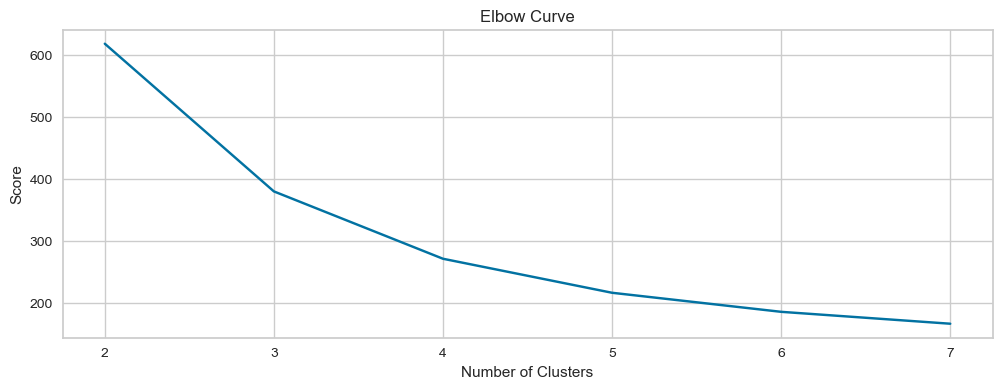

In [14]:
#Dataset 4

#Seleccionamos un rango de clusters a analizar
n_clusters=[2, 3, 4, 5, 6, 7]

fig, ax = plt.subplots(3, 2, figsize=(12,12))
scores=[]
for c in n_clusters:
    #definimos el metodo KMeans
    km = KMeans(n_clusters=c, init='k-means++', n_init=10, random_state=123)
    q, mod = divmod(c, 2)
    km.fit(X_circle)

    #recolectamos en un vector los valores de inertia
    scores.append(km.inertia_)

    #calculamos el silhouette score y mostramos su grafica
    score = silhouette_score(X_circle, km.labels_, metric='euclidean')
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    leyenda= "Valor Promedio Coeficiente: %.3f" % (score)
    visualizer.set_title(leyenda)
    visualizer.fit(X_circle)
plt.show()

#Graficamos los valores de inertia para cada numero de cluster
plt.figure(figsize=(12,4))
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.plot(n_clusters,scores)
plt.show()

### <font color='red'> Pregunta 5: <font color='black'> Redacta de la manera más específica las conclusiones que puedes sacar con las gráficas para cada una de las bases de datos


### <font color='red'> Responde aqui

Data 1:
Los valores del coeficiente promedio son altos para n_clusters = 3, pero aun es mayor para n_clusters=2. Tambien podemos observar claramente el “codo” en n_clusters = 3

Data 2:
Resultado similar al dataset 1 en cuanto al coeficiente. Sin embargo, en este caso el codo de la curva queda situado mas bien en n_cluster = 5.


Data 3:
Para este caso obtenemos un coeficiente muy alto para n_clusters=2. No se llega a ver ningun codo en la grafica.


Data 4:
En este caso tenemos valores muy malos, tanto en los coeficientes(ninguno supera el 0,4), como en la grafica (no se observa ningun codo en ella)




# c) Desbalance de los datos:


Explicaremos a continuación como el algoritmo puede ser susceptible a la cantidad de muestras de cada clase. Trabajaremos con el dataset 3, utilizaremos una herramienta llamada SMOTE que genera datos sintéticos interpolando los ya existentes. **Muestra la gráfica con los datos X_balanced y y_balanced, explica lo que ves y compara con la figura de este mismo dataset.**


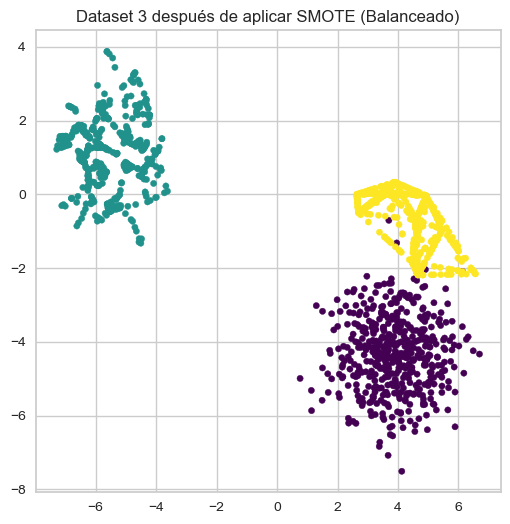

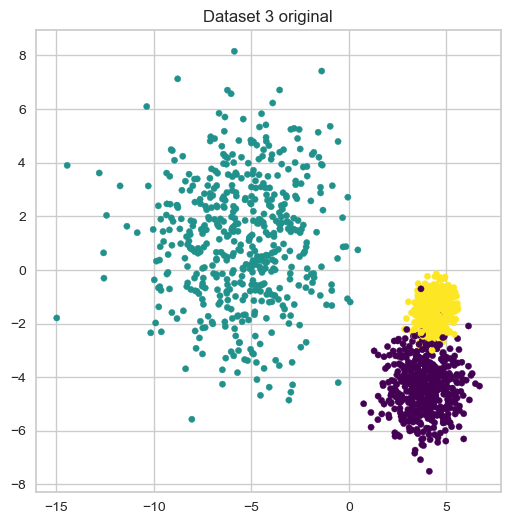

In [27]:
X_balanced, y_balanced= SMOTE(random_state=123).fit_resample(X_filtered, y_filtered)

#continua el codigo aqui para mostrar el data set
plt.figure(figsize=(6,6))
plt.scatter(X_balanced[:,0], X_balanced[:,1], c=y_balanced, cmap='viridis', s=20)
plt.title('Dataset 3 después de aplicar SMOTE (Balanceado)')
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(X_varied[:,0], X_varied[:,1], c=y_varied, cmap='viridis', s=20)
plt.title('Dataset 3 original')
plt.show()


### <font color='red'> Pregunta 6: <font color='black'> ¿En que cambió el data set? Explica lo que ves en la figura que has creado, intenta visualizar que ha hecho el método SMOTE y explicalo.


### <font color='red'> Responde aqui

Despues de aplicar el metodo SMOTE, los clusters ahora tienen una cantidad de puntos similar. Los límites entre clusters se ven más equilibrados y homogéneos. Visualmente, los grupos son más comparables en tamaño y densidad, lo que permitirá a K-means encontrar centroides más representativos para cada uno. En conclusión, esperamos una mejora en la calidad del clustering, tanto en la elbow curve como en el silhouette score, al reducir el sesgo hacia el grupo mayoritario.

**Aplica el algoritmo de `KMeans` y muestra el resultado de las predicciones**

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

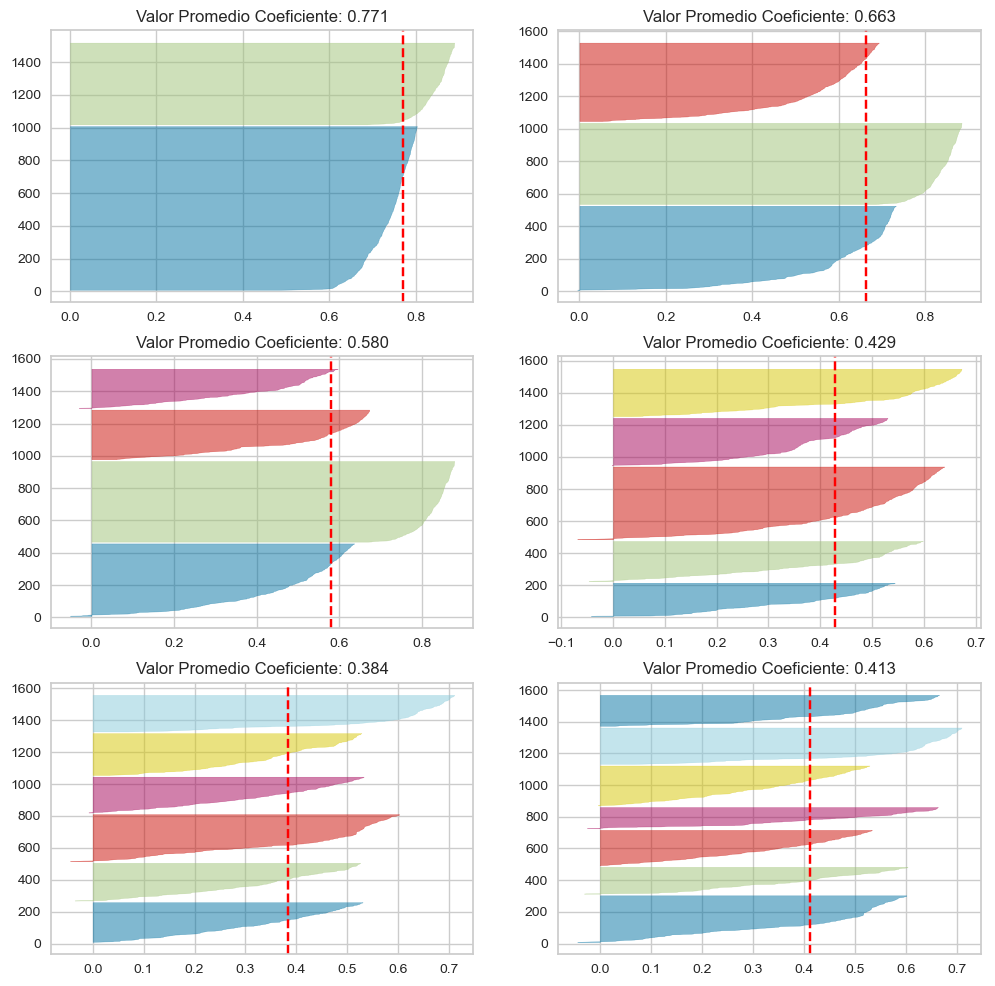

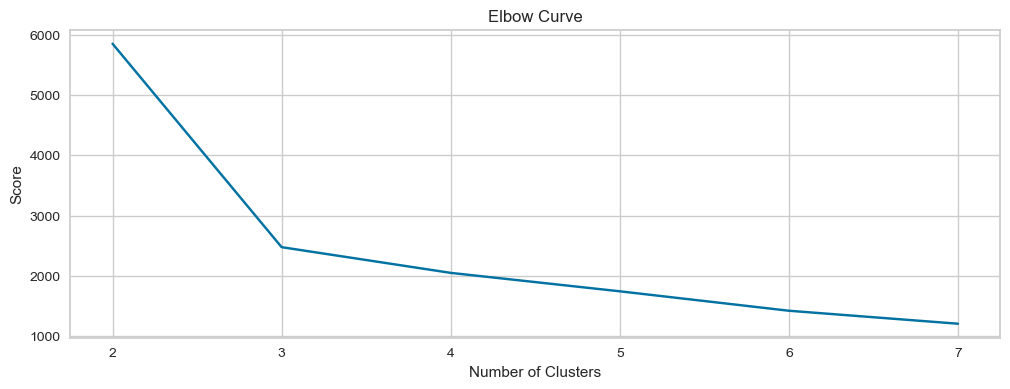

In [28]:
#continua el codigo aqui aplicando Kmean al dataset balanceado y muestra las predicciones
#Dataset 2

#Seleccionamos un rango de clusters a analizar
n_clusters=[2, 3, 4, 5, 6, 7]

fig, ax = plt.subplots(3, 2, figsize=(12,12))
scores=[]
for c in n_clusters:
    #definimos el metodo KMeans
    km = KMeans(n_clusters=c, init='k-means++', n_init=10, random_state=123)
    q, mod = divmod(c, 2)
    km.fit(X_balanced)

    #recolectamos en un vector los valores de inertia
    scores.append(km.inertia_)

    #calculamos el silhouette score y mostramos su grafica
    score = silhouette_score(X_balanced, km.labels_, metric='euclidean')
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    leyenda= "Valor Promedio Coeficiente: %.3f" % (score)
    visualizer.set_title(leyenda)
    visualizer.fit(X_balanced)
plt.show()

#Graficamos los valores de inertia para cada numero de cluster
plt.figure(figsize=(12,4))
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.plot(n_clusters,scores)
plt.show()

### <font color='red'> Pregunta 7: <font color='black'> ¿Como es ahora el agrupamiento?, respecto a no utilizar SMOTE

### <font color='red'> Responde aqui

Vemos que ahora el algoritmo funciona mucho mejor, ya que hemos conseguido incrementar significativamente el valor del coeficiente para n_clusters=3. Ademas, ahora en la grafica, el codo es perfectamente visible para n_clusters=3.

# d) Limitaciones de forma:


Para finalizar con ayuda de la documentación del metodo K-mean, **Explora diferentes configuraciones para trabajar con la base de datos 4.**

In [30]:
from sklearn.preprocessing import StandardScaler

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

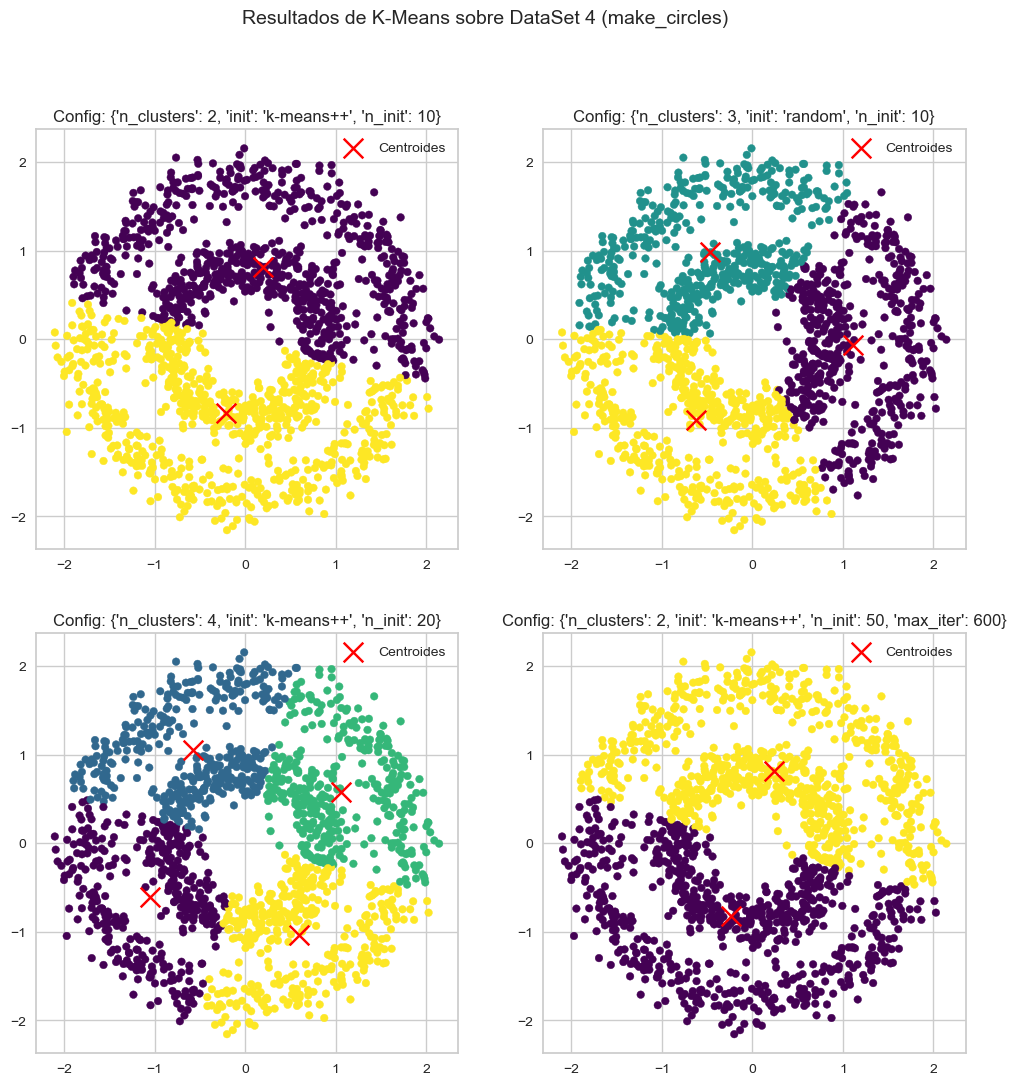

In [31]:
#continua el codigo aqui agrega tantos experimentos como sean necesarios para explicar tus resultados
# Escalamos los datos para mejorar la estabilidad numérica
scaler = StandardScaler()
X_circle_scaled = scaler.fit_transform(X_circle)

# Distintas configuraciones de KMeans
configs = [
    {'n_clusters': 2, 'init': 'k-means++', 'n_init': 10},
    {'n_clusters': 3, 'init': 'random', 'n_init': 10},
    {'n_clusters': 4, 'init': 'k-means++', 'n_init': 20},
    {'n_clusters': 2, 'init': 'k-means++', 'n_init': 50, 'max_iter': 600}
]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.ravel()

for i, config in enumerate(configs):
    kmeans = KMeans(**config, random_state=123)
    y_pred = kmeans.fit_predict(X_circle_scaled)
    
    axs[i].scatter(X_circle_scaled[:, 0], X_circle_scaled[:, 1], c=y_pred, cmap="viridis", s=30)
    axs[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                   c='red', marker='x', s=200, label='Centroides')
    axs[i].set_title(f"Config: {config}")
    axs[i].legend()

plt.suptitle("Resultados de K-Means sobre DataSet 4 (make_circles)", fontsize=14)
plt.show()


### <font color='red'> Pregunta 8: <font color='black'> ¿Hay alguna configuración que funcione?


### <font color='red'> Responde aqui
